important Libraries:-  This cell imports necessary libraries for building and training a neural network.
 It includes

  numpy for numerical operations,

  pandas for data manipulation, and
  
  various modules from tensorflow.keras for defining the neural network model, layers, and loss functions like Dense, Input, Sequential, and MeanSquaredError

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError

This cell uses the kagglehub library to download the 'coffee-roasting' dataset from Kaggle. The local path where the dataset is downloaded is stored in the path variable.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("youssefahmed2612/coffee-roasting")

Using Colab cache for faster access to the 'coffee-roasting' dataset.


This cell imports the os module (though not explicitly used in the final version of the code, it's common for path manipulations). It then reads the CoffeeRoasting.csv file, located at the path obtained from Kaggle, into a pandas DataFrame named data.

In [ ]:
import os
# print(os.listdir(path))
data = pd.read_csv(os.path.join(path, 'CoffeeRoasting.csv'))

This cell displays the first 5 rows of the data DataFrame using data.head(). This is a common practice for quickly inspecting the structure and initial content of a dataset.

In [ ]:
data.head()

,Temprature,Duration,Target
0,185.32,12.69,1
1,259.92,11.87,0
2,231.01,14.41,0
3,175.37,11.72,0
4,187.12,14.13,1


This cell attempts to reshape the y variable. Based on the commented-out line, y was intended to be the 'Target' column from the data DataFrame, reshaped to a column vector. The output shows the reshaped y array, which represents the target labels (good or bad coffee).

In [ ]:
# y=np.array(data['Target']) # Column 'Target' was dropped from data
y=y.reshape(-1,1)
print(y)

[[1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]

This cell first removes the 'Target' column from the data DataFrame using data.drop('Target', axis=1, inplace=True). Then, it converts the remaining features (Temperature and Duration) into a NumPy array X, which will serve as the input features for the neural network.

In [ ]:
data.drop('Target',axis=1,inplace=True)
X=np.array(data)
print(X)

[[185.32  12.69]
 [259.92  11.87]
 [231.01  14.41]
 [175.37  11.72]
 [187.12  14.13]
 [225.91  12.1 ]
 [208.41  14.18]
 [207.08  14.03]
 [280.6   14.23]
 [202.87  12.25]
 [196.7   13.54]
 [270.31  14.6 ]
 [192.95  15.2 ]
 [213.57  14.28]
 [164.47  11.92]
 [177.26  15.04]
 [241.77  14.9 ]
 [237.    13.13]
 [219.74  13.87]
 [266.39  13.25]
 [270.45  13.95]
 [261.96  13.49]
 [243.49  12.86]
 [220.58  12.36]
 [163.59  11.65]
 [244.76  13.33]
 [271.19  14.84]
 [201.99  15.39]
 [229.93  14.56]
 [204.97  12.28]
 [173.19  12.22]
 [231.51  11.95]
 [152.69  14.83]
 [163.42  13.3 ]
 [215.95  13.98]
 [218.04  15.25]
 [251.3   13.8 ]
 [233.33  13.53]
 [280.24  12.41]
 [243.02  13.72]
 [155.67  12.68]
 [275.17  14.64]
 [151.73  12.69]
 [151.32  14.81]
 [164.9   11.73]
 [282.55  13.28]
 [192.98  11.7 ]
 [202.6   12.96]
 [220.67  11.53]
 [169.97  12.34]
 [209.47  12.71]
 [232.8   12.64]
 [272.8   15.35]
 [158.02  12.34]
 [226.01  14.58]
 [158.64  12.24]
 [211.66  14.17]
 [271.95  14.97]
 [257.16  11.7

This cell performs feature normalization. It first prints the maximum and minimum values for 'Temperature' and 'Duration' before normalization. Then, it initializes a tf.keras.layers.Normalization layer, adapts it to the input data X (meaning it learns the mean and variance of each feature), and finally normalizes X to Xn. It concludes by printing the max and min values of the normalized features to demonstrate the effect of scaling.

In [ ]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


This cell artificially expands the normalized feature dataset Xn and the target dataset y by tiling them 1000 times. This creates Xt and Yt, which are significantly larger datasets (200,000 samples each). This is often done to increase the effective size of the training data or to ensure a sufficient number of training steps.

In [ ]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(y.reshape(-1,1),(1000,1))
print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


This cell defines a sequential Keras model, which is a simple feed-forward neural network. It sets a random seed for reproducibility. The model consists of an input layer with 2 features, a hidden Dense layer named 'L1' with 3 units and a 'sigmoid' activation function, and an output Dense layer named 'L2' with 1 unit and a 'sigmoid' activation function (suitable for binary classification).

In [ ]:
tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation='sigmoid', name = 'L1'),
        Dense(1, activation='sigmoid', name = 'L2')
     ]
)

This cell displays a summary of the defined Keras model using model.summary(). This output provides details about each layer, including its name, output shape, and the number of trainable parameters.

In [ ]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

This cell manually calculates and prints the number of parameters (weights and biases) for the first and second dense layers of the model. This helps verify the parameter counts reported by model.summary().

In [ ]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


This cell retrieves and prints the initial weights (W) and biases (b) for both the 'L1' and 'L2' layers of the neural network before training. It also shows their shapes, providing insight into the model's randomly initialized state.

In [ ]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-1.0202154   0.2988894   0.23647237]
 [-0.9144792   0.88935757 -0.34515435]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[ 0.7663238 ]
 [-0.21702874]
 [ 0.8415929 ]] 
b2(1,): [0.]


This cell compiles and trains the neural network. It configures the model with BinaryCrossentropy as the loss function (appropriate for binary classification), the Adam optimizer with a learning rate of 0.001, and tracks 'accuracy', 'precision', and 'recall' as metrics. The model is then trained for 10 epochs using the expanded datasets Xt and Yt, with 20% of the data set aside for validation.

In [ ]:

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history = model.fit(
    Xt,
    Yt,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7601 - loss: 0.4614 - precision: 0.2976 - recall: 0.0852 - val_accuracy: 0.7850 - val_loss: 0.3843 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8282 - loss: 0.3453 - precision: 0.7372 - recall: 0.3122 - val_accuracy: 0.8750 - val_loss: 0.3017 - val_precision: 0.8000 - val_recall: 0.5581
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8934 - loss: 0.2690 - precision: 0.7946 - recall: 0.6802 - val_accuracy: 0.9100 - val_loss: 0.2468 - val_precision: 0.8205 - val_recall: 0.7442
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9117 - loss: 0.2370 - precision: 0.8067 - recall: 0.7750 - val_accuracy: 0.9150 - val_loss: 0.2303 - val_precision: 0.8095 - val_recall: 0.7907
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9149 - loss: 0.2270 - precision: 0.8096 - recall: 0.7899 - val_accuracy

This cell plots the training loss and validation loss over the training epochs. It uses the history object (returned by model.fit) to get these values and then displays them with a legend, x-axis label ('Epoch'), and y-axis label ('Loss'). This visualization is crucial for understanding the model's learning progress and detecting overfitting.

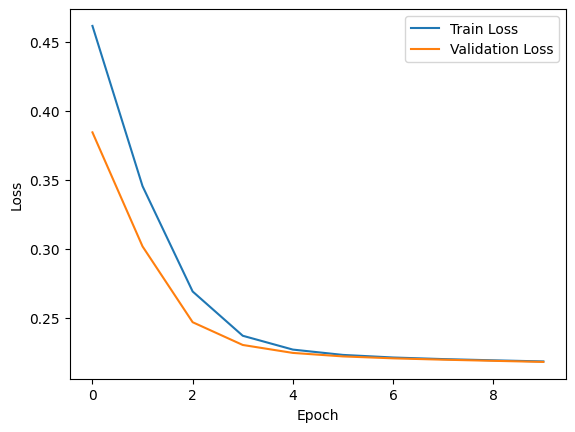

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

This cell also plots the training loss over the epochs, similar to the previous cell, but specifically focuses only on the training loss. It adds a title, and labels for the axes.

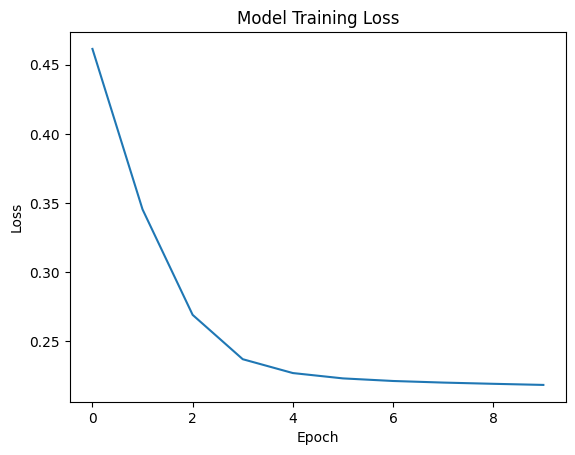

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

This cell retrieves and prints the final learned weights (W) and biases (b) for both the 'L1' and 'L2' layers of the model after the training process is complete. Comparing these to the initial weights (from cell f08cviWn8UVS) shows how the model has adjusted its parameters to minimize the loss.

In [ ]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-9.395224    6.788341    4.9715905 ]
 [-0.87271446  5.060294    0.8858272 ]] 
b1: [2.0747852  0.20062898 5.5671806 ]
W2:
 [[ 0.4620569]
 [-7.036419 ]
 [ 6.2797427]] 
b2: [-4.3129735]


This cell visualizes the original coffee roasting data using a scatter plot. It separates 'Bad Coffee' (Target=0) and 'Good Coffee' (Target=1) by plotting them with different colors and labels. The plot shows 'Temperature' on the x-axis and 'Duration' on the y-axis, providing a visual representation of the data distribution.

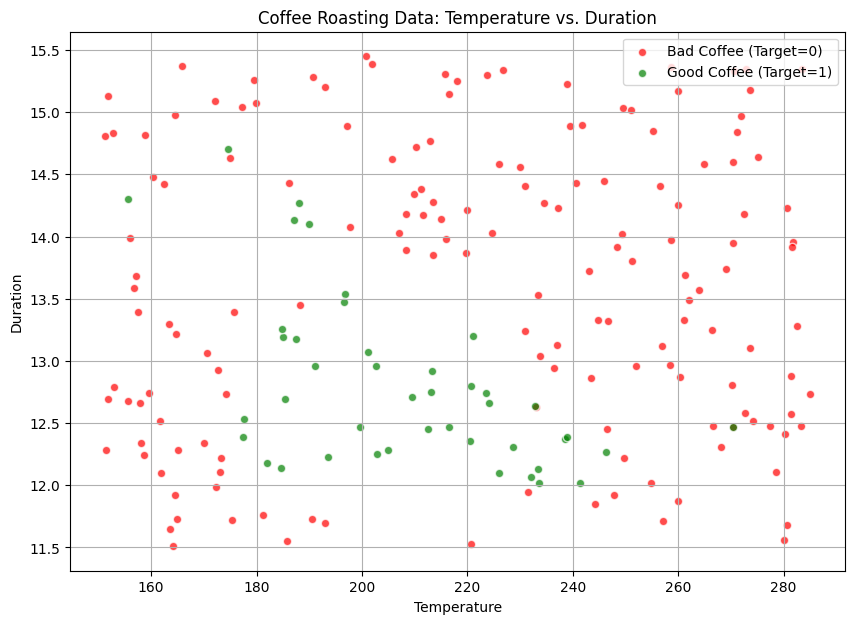

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))

# Plot scatter points for Target=0 and Target=1 separately for clear legend entries
plt.scatter(data['Temprature'][y.flatten()==0], data['Duration'][y.flatten()==0],
            label='Bad Coffee (Target=0)', alpha=0.7, color='red', edgecolors='w')
plt.scatter(data['Temprature'][y.flatten()==1], data['Duration'][y.flatten()==1],
            label='Good Coffee (Target=1)', alpha=0.7, color='green', edgecolors='w')

plt.xlabel('Temperature')
plt.ylabel('Duration')
plt.title('Coffee Roasting Data: Temperature vs. Duration')

plt.legend(loc='upper right') # Display legend for all plotted elements
plt.grid(True)
plt.show()

This cell demonstrates how to make predictions with the trained model on new, unseen data. It defines three test examples X_test, normalizes them using the norm_l layer (which was adapted to the training data), and then uses the model.predict() method to get the raw probability outputs for each test example.

In [ ]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17],  # negative example
    [200,5]])
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
predictions = 
 [[0.5444327 ]
 [0.009627  ]
 [0.02550831]]


This cell converts the continuous probability predictions (obtained from the previous cell) into binary class labels (0 or 1). It applies a threshold of 0.5: if a prediction is 0.5 or greater, it's classified as 1 (Good Coffee); otherwise, it's classified as 0 (Bad Coffee). The resulting binary decisions are then printed.

In [ ]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]
 [0]]
